# SDP hierarchy per la discriminazione di 2 stati

**Rilassamento SDP** del problema di **state discrimination a 2 stati** nel framework dell'articolo *Prepare-and-measure scenarios with photon-number constraints*.

Scenario:
- Alice prepara $\rho_0$ oppure $\rho_1$;
- Bob fa una misura binaria con proiettore $M$ (l'altro outcome è $I-M$);
- il vincolo fisico è sul peso del vacuum state:

$$\langle 0|\rho_x|0\rangle=\operatorname{Tr}(\rho_x\sigma_0)\ge 1-\omega_x,\;\;\omega_1=\omega_2=\omega$$

con $\sigma_0=|0\rangle\langle0|$ proiettore nello stato di Fock $|0\rangle$.

La probabilità media di successo è
$$W_{2\mathrm{disc}}=\frac12p(0|0)+\frac12p(1|1)$$

Poiché $p(0|0)=\operatorname{Tr}(\rho_0M)$ e $p(1|1)=\operatorname{Tr}(\rho_1(I-M))$, allora

$$W_{2\mathrm{disc}}=\frac12+\frac12\operatorname{Tr}(\rho_0M)-\frac12\operatorname{Tr}(\rho_1M)$$

Analiticamente si trova che il valore ottimale è

$$W^Q_{2\mathrm{disc}}=\frac12+\sqrt{\omega(1-\omega)}$$


## 1. Import

In [2]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

## 2. Moment matrix

Invece di cercare direttamente matrici per $\rho_0,\rho_1,M,\sigma_0$, introduciamo una **moment matrix** $\Gamma$.

Introduciamo un insieme $\mathbb{O}$ di liste di operatori che servono a caratterizzare il problema. 


Le righe e colonne della matrice $\Gamma$ sono indicizzate da **parole non commutative negli operatori**, per esempio (in questo caso al primo livello $k=1$):

$$\mathbb{S_1} = \left\{I,\quad \rho_0,\quad M,\quad \sigma_0,\quad \rho_0M\right\}$$

Gli elementi sono

$$\Gamma_{u,v}=\operatorname{Tr}(u^\dagger v) \quad \forall u,v \in \mathbb{S_1}$$

Se gli operatori esistono davvero, allora necessariamente, per costruzione

$$\Gamma\succeq0.$$

Quindi l'SDP cerca valori compatibili per i momenti.


## 3. Parole non commutative in Python

Una singola parola può essere rappresentata, per comodità, come una tupla di stringhe i.e

```python
("r0", "M")
```

significa $\rho_0M$.

La tupla vuota `()` rappresenta l'identità $I$.

Uso:
- `"r0"` per $\rho_0$;
- `"r1"` per $\rho_1$;
- `"M"` per il proiettore di Bob;
- `"S"` per $\sigma_0$.


In [3]:
# M e S sono proiettori: M^2=M, S^2=S.
# rho_0 e rho_1 sono, in generale, stati misti.
projs = {"M", "S"}


## 4. Riduzione delle parole

Si possono sempre apportare semplificazioni nelle parole, dovute ad esempio in questo caseo alle relazioni dei proiettori:

$$M^2=M,\qquad S^2=S.$$

Non c'è commutatività: $M\rho_0$ e $\rho_0M$ restano parole diverse.


In [4]:
def reduce_word(w):
    """Riduce una parola usando M^2=M e S^2=S."""
    w = list(w)
    changed = True
    while changed:
        changed = False
        out = []
        i = 0
        while i < len(w):
            if i + 1 < len(w) and w[i] == w[i + 1] and w[i] in projs:
                out.append(w[i])
                i += 2
                changed = True
            else:
                out.append(w[i])
                i += 1
        w = out
    return tuple(w)

# Esempio
print(reduce_word(("M", "M", "r0", "S", "S")))


('M', 'r0', 'S')


## 5. Ciclicità della traccia

La traccia soddisfa

$$\operatorname{Tr}(ABC)=\operatorname{Tr}(BCA)=\operatorname{Tr}(CAB).$$

Quindi parole che differiscono per rotazioni cicliche rappresentano lo stesso momento.

Useremo una forma canonica per non creare variabili duplicate.

Per semplicità didattica, identifichiamo anche una parola con la parola invertita, coerente con operatori hermitiani e momenti reali in questo primo esempio.


In [5]:
def rotations(w):
    """Restituisce tutte le rotazioni cicliche della parola w"""
    if len(w) == 0:
        return [()]
    return [w[i:] + w[:i] for i in range(len(w))]

def canonical_trace_word(w):
    """Forma canonica di una parola dentro una traccia."""
    w = reduce_word(tuple(w))
    candidates = rotations(w) + rotations(tuple(reversed(w)))
    candidates = [reduce_word(c) for c in candidates]
    return min(candidates)

# Esempio
for word in [("r0", "M", "S"), ("M", "S", "r0"), ("S", "r0", "M")]:
    print(word, "->", canonical_trace_word(word))


('r0', 'M', 'S') -> ('M', 'S', 'r0')
('M', 'S', 'r0') -> ('M', 'S', 'r0')
('S', 'r0', 'M') -> ('M', 'S', 'r0')


## 6. Oggetto ausiliario `TracialSDP`

La funzione importante è `T(w)`, che rappresenta formalmente l'operazione di traccia.
Dunque:

```python
T(("r0", "M"))
```

sarà $\operatorname{Tr}(\rho_0M)$.

Se una parola non è ancora stata vista, creiamo una nuova variabile scalare CVXPY con connotazione `T_X`



In [6]:
class TracialSDP:
    def __init__(self):
        self.vars = {}

    def T(self, w):
        """Restituisce la variabile CVXPY associata a Tr(w)."""
        key = canonical_trace_word(tuple(w))
        if key not in self.vars:
            name = "T_I" if len(key) == 0 else "T_" + "".join(key)
            self.vars[key] = cp.Variable(name=name)
        return self.vars[key]

    def moment_matrix(self, words):
        """Costruisce Gamma con Gamma[u,v] = Tr(u^dagger v)."""
        n = len(words)
        G = [[None for _ in range(n)] for _ in range(n)]
        for i, u in enumerate(words):
            for j, v in enumerate(words):
                u_dagger = tuple(reversed(u))
                G[i][j] = self.T(u_dagger + tuple(v))
        return cp.bmat(G)

    def localizing_matrix(self, words, rho):
        """
        Costruisce la localizing matrix associata a rho - rho^2 >= 0.
        Elemento [u,v] = Tr(u^dagger (rho-rho^2) v).
        """
        n = len(words)
        L = [[None for _ in range(n)] for _ in range(n)]
        for i, u in enumerate(words):
            for j, v in enumerate(words):
                left = tuple(reversed(u))
                right = tuple(v)
                L[i][j] = self.T(left + (rho,) + right) - self.T(left + (rho, rho) + right)
        return cp.bmat(L)


## 7. Una piccola moment matrix esplicita

Costruiamo una moment matrix indicizzata da

$$\{I,\rho_0,M,S\}.$$


In [7]:
def word_to_str(w):
    return "I" if len(w) == 0 else " ".join(w)

small_words = [(), ("r0",), ("M",), ("S",)]
small_sdp = TracialSDP()
small_G = small_sdp.moment_matrix(small_words)

print("Parole di riga/colonna:")
for i, w in enumerate(small_words):
    print(i, word_to_str(w))

print("Variabili create:")
for key in sorted(small_sdp.vars.keys()):
    var = small_sdp.vars[key]
    print(f"{key}  -->  {var.name()}")


Parole di riga/colonna:
0 I
1 r0
2 M
3 S
Variabili create:
()  -->  T_I
('M',)  -->  T_M
('M', 'S')  -->  T_MS
('M', 'r0')  -->  T_Mr0
('S',)  -->  T_S
('S', 'r0')  -->  T_Sr0
('r0',)  -->  T_r0
('r0', 'r0')  -->  T_r0r0


## 9. SDP completa per 2-state discrimination

Vincoli:

1. moment matrix positiva:

$$\Gamma\succeq0$$

2. localizing matrices positive:

$$\Upsilon_x\succeq0$$

con

$$\Upsilon_x[u,v]=\operatorname{Tr}\left[u^\dagger(\rho_x-\rho_x^2)v\right]$$

3. normalizzazione degli stati:

$$\operatorname{Tr}(\rho_0)=\operatorname{Tr}(\rho_1)=1$$

4. normalizzazione del vuoto:

$$\operatorname{Tr}(S)=1$$

5. vincoli photon-number:

$$\operatorname{Tr}(\rho_xS)\ge1-\omega$$

Probabilità di successo:

$$\mathcal{W}=\frac12p(0|\rho_0)+\frac12p(1|\rho_1)=\frac12\operatorname{Tr}(\rho_0M)+\frac12\operatorname{Tr}(\rho_1(I-M))=\frac12+\frac12\operatorname{Tr}(\rho_0M)-\frac12\operatorname{Tr}(\rho_1M)$$

Obiettivo:

$$\max\mathcal{W}=\max\left[\frac12+\frac12\operatorname{Tr}(\rho_0M)-\frac12\operatorname{Tr}(\rho_1M)\right]\equiv\max_\Gamma\left[\frac12+\frac12\Gamma_{\rho_0,M}-\frac12\Gamma_{\rho_1,M}\right]$$


In [8]:
def solve_two_state_discrimination(omega, solver="CLARABEL", verbose=False):
    """
    Risolve un rilassamento SDP per il problema di discriminazione di 2 stati.

    omega controlla il vincolo Tr(rho_x S) >= 1 - omega.
    Piccolo omega = stati molto vicini al vuoto = più difficili da distinguere.
    """
    sdp = TracialSDP()

    # Lista di parole per Gamma.
    # Più parole -> rilassamento più forte (ma SDP più pesante).
    words = [
        (),
        ("r0",), ("r1",), ("M",), ("S",),
        ("r0", "M"), ("r1", "M"),
        ("r0", "r0"), ("r1", "r1"),
        ("S", "r0"), ("S", "r1"), ("S", "M"),
    ]

    # Parole per le localizing matrices.
    loc_words_r0 = [(), ("r0",), ("M",), ("S",)]
    loc_words_r1 = [(), ("r1",), ("M",), ("S",)]

    Gamma = sdp.moment_matrix(words)
    L0 = sdp.localizing_matrix(loc_words_r0, "r0")
    L1 = sdp.localizing_matrix(loc_words_r1, "r1")

    constraints = [Gamma >> 0, L0 >> 0, L1 >> 0]

    # Normalizzazione degli stati
    constraints += [sdp.T(("r0",)) == 1]
    constraints += [sdp.T(("r1",)) == 1]

    # Normalizzazione del proiettore del vuoto S=sigma_0
    constraints += [sdp.T(("S",)) == 1]

    # Vincolo sul peso del vuoto
    constraints += [sdp.T(("r0", "S")) >= 1 - omega]
    constraints += [sdp.T(("r1", "S")) >= 1 - omega]

    # Obiettivo: W = 1/2 + 1/2 Tr(r0 M) - 1/2 Tr(r1 M)
    W = 0.5 + 0.5 * sdp.T(("r0", "M")) - 0.5 * sdp.T(("r1", "M"))

    problem = cp.Problem(cp.Maximize(W), constraints)
    problem.solve(solver=solver, verbose=verbose)

    analytic = 0.5 + np.sqrt(omega * (1 - omega))

    return {
        "omega": omega,
        "sdp_upper_bound": problem.value,
        "analytic": analytic,
        "absolute_error": None if problem.value is None else abs(problem.value - analytic),
        "status": problem.status,
        "num_moment_variables": len(sdp.vars),
        "moment_variables": sdp.vars,
    }


## 10. Test numerico

Per vari valori di $\omega$ confrontiamo il valore SDP con

$$\frac12+\sqrt{\omega(1-\omega)}.$$

Tenendo in considerazione che il valore SDP è un upper bound.


In [12]:
omegas = [0.01, 0.05, 0.10, 0.25, 0.50]
results = []

for omega in omegas:
    res = solve_two_state_discrimination(omega, solver="CLARABEL")
    results.append(res)

for res in results:
    print(
        f"omega={res['omega']:.3f} | "
        f"SDP={res['sdp_upper_bound']:.10f} | "
        f"analytic={res['analytic']:.10f} | "
        f"err={res['absolute_error']:.2e} | "
        f"status={res['status']}"
    )

omega=0.010 | SDP=0.6035033354 | analytic=0.5994987437 | err=4.00e-03 | status=optimal
omega=0.050 | SDP=0.7320473086 | analytic=0.7179449472 | err=1.41e-02 | status=optimal
omega=0.100 | SDP=0.8199997063 | analytic=0.8000000000 | err=2.00e-02 | status=optimal
omega=0.250 | SDP=0.9497591922 | analytic=0.9330127019 | err=1.67e-02 | status=optimal
omega=0.500 | SDP=1.0000000026 | analytic=1.0000000000 | err=2.60e-09 | status=optimal


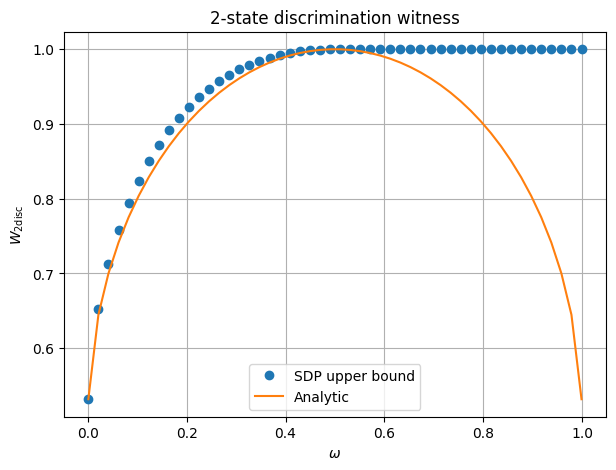

In [10]:
omegas = np.linspace(0.001, 0.999, 50)

sdp_values = []
analytic_values = []

for omega in omegas:
    res = solve_two_state_discrimination(omega)
    sdp_values.append(res["sdp_upper_bound"])
    analytic_values.append(res["analytic"])

plt.figure(figsize=(7, 5))
plt.plot(omegas, sdp_values, "o", label="SDP upper bound")
plt.plot(omegas, analytic_values, "-", label="Analytic")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$W_{2\mathrm{disc}}$")
plt.title("2-state discrimination witness")
plt.legend()
plt.grid(True)
plt.show()